In [2]:
!git clone https://github.com/santoshshresth/Amex.git

Cloning into 'Amex'...


In [3]:
cd Amex

C:\Users\HP\Amex


In [4]:
cd data

C:\Users\HP\Amex\data


In [5]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 0CA4-CD14

 Directory of C:\Users\HP\Amex\data

27-04-2026  22:12    <DIR>          .
27-04-2026  22:12    <DIR>          ..
27-04-2026  22:12         7,564,965 cs-training.csv
               1 File(s)      7,564,965 bytes
               2 Dir(s)  179,282,042,880 bytes free


In [11]:
import pandas as pd

df=pd.read_csv("cs-training.csv")
print(df.shape)

(150000, 12)


In [12]:
df.sample(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
145099,145100,0,0.000229,68,0,0.000000,NaN,4,0,0,0,0.0
104118,104119,0,1.126582,30,0,0.027072,2400.0,6,0,0,0,2.0
26308,26309,0,1.000000,46,0,0.000000,6000.0,1,0,0,1,4.0
134871,134872,0,1.000000,37,0,0.072664,2600.0,1,0,0,0,1.0
145456,145457,0,0.000000,35,0,0.377276,2525.0,12,0,1,0,1.0


In [13]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [14]:
(df.isnull().sum() / len(df)) * 100

Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

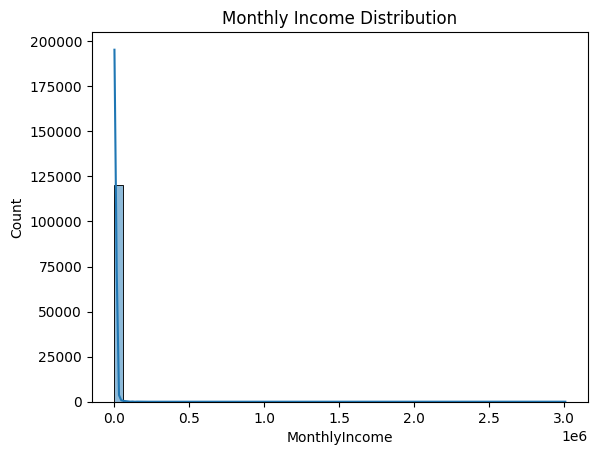

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['MonthlyIncome'], bins=50, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

<Axes: xlabel='NumberOfDependents', ylabel='Count'>

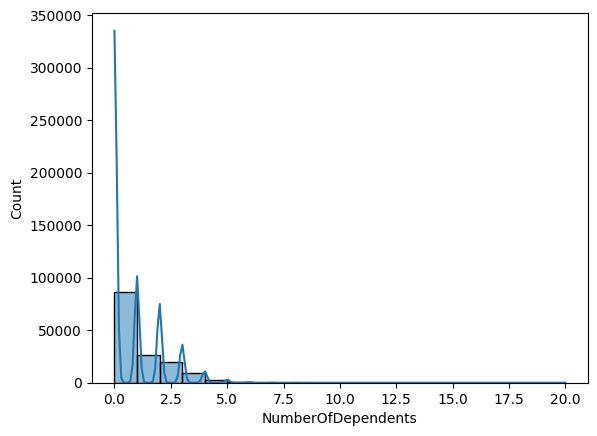

In [16]:
sns.histplot(df['NumberOfDependents'], bins=20, kde=True)

In [17]:
df['MonthlyIncome'].skew(), df['NumberOfDependents'].skew()


(np.float64(114.04031794523321), np.float64(1.5882423788858833))

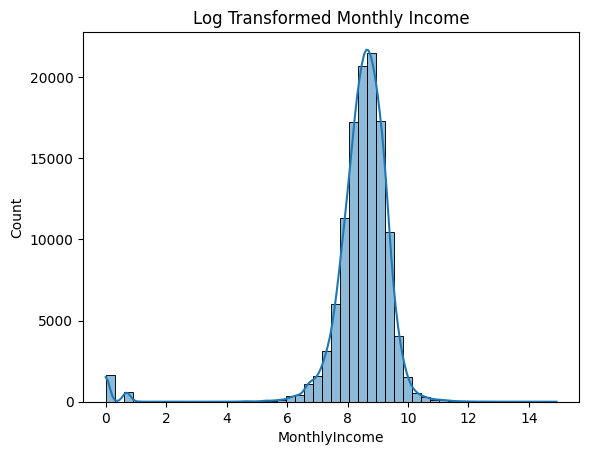

In [18]:
import numpy as np

sns.histplot(np.log1p(df['MonthlyIncome']), bins=50, kde=True)
plt.title("Log Transformed Monthly Income")
plt.show()

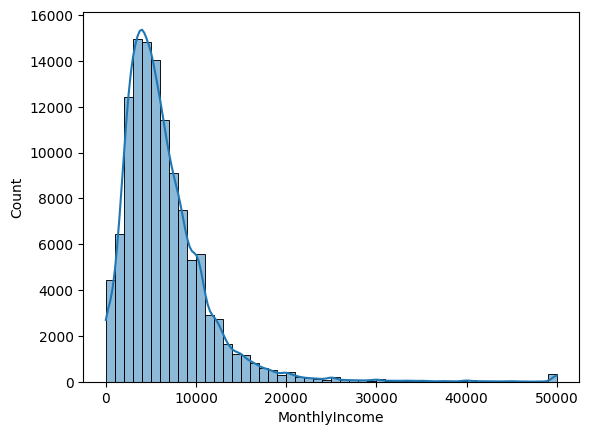

In [19]:
sns.histplot(df['MonthlyIncome'].clip(upper=50000), bins=50, kde=True)
plt.show()

In [32]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isnull().astype(int)


In [34]:
df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_21144\74027484.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MonthlyIncome']=df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)


In [37]:
df['NumberOfDependents']=df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_21144\2306651885.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['NumberOfDependents']=df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)


In [38]:
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [39]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0


In [40]:
df.drop(columns=['Unnamed: 0'], inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

In [41]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_missing                   0
dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled_np = scaler.fit_transform(X_train)
X_test_scaled_np = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled_np,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_np,
    columns=X_test.columns,
    index=X_test.index
)

In [56]:
X_train_scaled

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
104025,-0.022803,-1.576975,-0.100746,-0.180840,-0.151997,-0.672522,-0.063764,-0.900750,-0.057706,-0.666180,-0.495947
5415,-0.020393,0.184209,-0.100746,-0.180416,-0.334990,0.493412,-0.063764,-0.017611,-0.057706,-0.666180,-0.495947
75612,-0.022803,-0.628645,-0.100746,-0.180824,-0.164834,-1.255488,-0.063764,-0.900750,-0.057706,2.944145,-0.495947
138169,-0.021217,-0.831859,-0.100746,-0.180815,0.187732,-1.255488,-0.063764,-0.900750,-0.057706,3.846727,-0.495947
87184,-0.022803,-1.170548,-0.100746,-0.180777,-0.045659,0.687734,-0.063764,-0.017611,-0.057706,-0.666180,-0.495947
...,...,...,...,...,...,...,...,...,...,...,...
119879,-0.022369,1.335753,-0.100746,-0.180383,-0.176941,1.659345,-0.063764,0.865527,-0.057706,0.236401,-0.495947
103694,-0.022448,0.997064,0.137824,0.736676,-0.074832,0.299089,-0.063764,-0.017611,-0.057706,0.236401,2.016344
131932,-0.022525,-0.222218,-0.100746,-0.180499,-0.264462,-0.089555,-0.063764,0.865527,-0.057706,-0.666180,-0.495947
146867,-0.021914,-1.102810,-0.100746,-0.180833,-0.359277,-1.255488,-0.063764,-0.900750,-0.057706,-0.666180,-0.495947


In [57]:
cd C:\Users\HP\Amex

C:\Users\HP\Amex


In [60]:
!code .

'code' is not recognized as an internal or external command,
operable program or batch file.
